# 3. Wymiar Minkowskiego (Box-Counting)

## Wprowadzenie

**Wymiar Minkowskiego** (zwany też wymiarem pudełkowym lub box-counting dimension) jest jedną z najpopularniejszych metod numerycznego wyznaczania wymiaru fraktalnego.

### Definicja

Dla zbioru $F$ w przestrzeni metrycznej:

$$\dim_{box}(F) = \lim_{\epsilon \to 0} \frac{\log N(\epsilon)}{\log(1/\epsilon)}$$

gdzie $N(\epsilon)$ to minimalna liczba "pudełek" o rozmiarze $\epsilon$ potrzebna do pokrycia zbioru $F$.

### Algorytm numeryczny

1. Dla różnych wartości $\epsilon$, oblicz $N(\epsilon)$
2. Wykreśl punkty $(\log(1/\epsilon), \log N(\epsilon))$
3. Dopasuj prostą metodą najmniejszych kwadratów
4. **Wymiar = nachylenie prostej**

In [1]:
# Importy
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys
sys.path.insert(0, '..')

from src.box_counting import box_count, box_counting_dimension, function_to_points, curve_to_points
from src.weierstrass import weierstrass_function, theoretical_dimension as weierstrass_dim
from src.space_filling import hilbert_curve

# Konfiguracja
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Moduły załadowane pomyślnie!")

Moduły załadowane pomyślnie!


## 3.1 Weryfikacja algorytmu na znanych przykładach

Przetestujmy algorytm box-counting na obiektach o znanym wymiarze.

In [2]:
# Test 1: Prosta linia (wymiar = 1)
print("Test 1: Prosta linia y = x")
print("=" * 50)

x_line = np.linspace(0, 1, 2000)
y_line = x_line
points_line = np.column_stack([x_line, y_line])

dim_line, r2_line, details_line = box_counting_dimension(points_line)

print(f"Oczekiwany wymiar: 1.0")
print(f"Obliczony wymiar:  {dim_line:.4f}")
print(f"Błąd:              {abs(dim_line - 1.0):.4f}")
print(f"R²:                {r2_line:.4f}")

Test 1: Prosta linia y = x
Oczekiwany wymiar: 1.0
Obliczony wymiar:  0.9895
Błąd:              0.0105
R²:                0.9999


In [3]:
# Test 2: Kwadrat wypełniony (wymiar = 2)
print("\nTest 2: Kwadrat wypełniony losowymi punktami")
print("=" * 50)

np.random.seed(42)
points_square = np.random.rand(10000, 2)

dim_square, r2_square, details_square = box_counting_dimension(
    points_square,
    epsilon_min=0.01,
    epsilon_max=0.3,
    n_epsilons=20
)

print(f"Oczekiwany wymiar: 2.0")
print(f"Obliczony wymiar:  {dim_square:.4f}")
print(f"Błąd:              {abs(dim_square - 2.0):.4f}")
print(f"R²:                {r2_square:.4f}")


Test 2: Kwadrat wypełniony losowymi punktami
Oczekiwany wymiar: 2.0
Obliczony wymiar:  1.8803
Błąd:              0.1197
R²:                0.9973


In [4]:
# Test 3: Okrąg (wymiar = 1)
print("\nTest 3: Okrąg jednostkowy")
print("=" * 50)

theta = np.linspace(0, 2*np.pi, 2000)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
points_circle = np.column_stack([x_circle, y_circle])

dim_circle, r2_circle, details_circle = box_counting_dimension(points_circle)

print(f"Oczekiwany wymiar: 1.0")
print(f"Obliczony wymiar:  {dim_circle:.4f}")
print(f"Błąd:              {abs(dim_circle - 1.0):.4f}")
print(f"R²:                {r2_circle:.4f}")


Test 3: Okrąg jednostkowy
Oczekiwany wymiar: 1.0
Obliczony wymiar:  0.9253
Błąd:              0.0747
R²:                0.9898


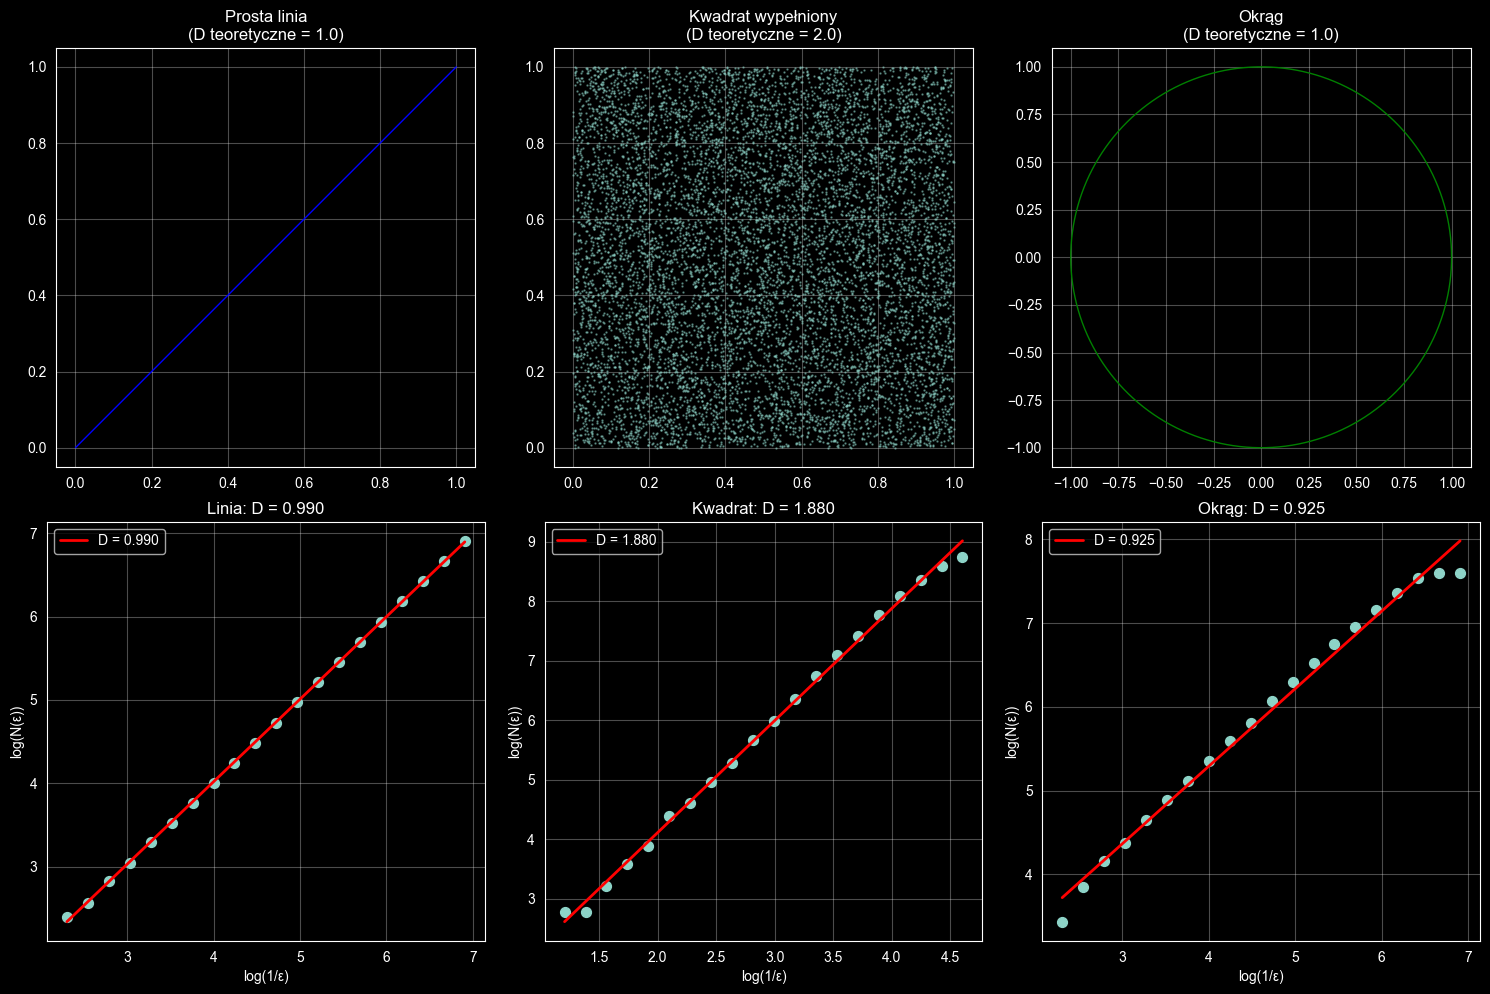

In [5]:
# Wizualizacja testów
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Górny rząd - obiekty
axes[0, 0].plot(x_line, y_line, 'b-', linewidth=1)
axes[0, 0].set_title('Prosta linia\n(D teoretyczne = 1.0)')
axes[0, 0].set_aspect('equal')

axes[0, 1].scatter(points_square[:, 0], points_square[:, 1], s=0.5, alpha=0.5)
axes[0, 1].set_title('Kwadrat wypełniony\n(D teoretyczne = 2.0)')
axes[0, 1].set_aspect('equal')

axes[0, 2].plot(x_circle, y_circle, 'g-', linewidth=1)
axes[0, 2].set_title('Okrąg\n(D teoretyczne = 1.0)')
axes[0, 2].set_aspect('equal')

# Dolny rząd - regresja box-counting
for ax, details, dim, name in [
    (axes[1, 0], details_line, dim_line, 'Linia'),
    (axes[1, 1], details_square, dim_square, 'Kwadrat'),
    (axes[1, 2], details_circle, dim_circle, 'Okrąg')
]:
    ax.scatter(details['log_inv_eps'], details['log_counts'], s=50)
    ax.plot(details['log_inv_eps'],
            details['slope'] * details['log_inv_eps'] + details['intercept'],
            'r-', linewidth=2, label=f'D = {dim:.3f}')
    ax.set_xlabel('log(1/ε)')
    ax.set_ylabel('log(N(ε))')
    ax.set_title(f'{name}: D = {dim:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../output/figures/box_counting_verification.png', dpi=150)
plt.show()

## 3.2 Trójkąt Sierpińskiego

Trójkąt Sierpińskiego to klasyczny fraktal o teoretycznym wymiarze:

$$D = \frac{\log 3}{\log 2} \approx 1.585$$

In [6]:
# Generowanie trójkąta Sierpińskiego metodą chaosu
def sierpinski_chaos(n_points=50000):
    """Generuje trójkąt Sierpińskiego metodą gry w chaos."""
    # Wierzchołki trójkąta
    vertices = np.array([
        [0, 0],
        [1, 0],
        [0.5, np.sqrt(3)/2]
    ])
    
    # Punkt startowy
    point = np.array([0.5, 0.25])
    points = [point.copy()]
    
    for _ in range(n_points - 1):
        # Wybierz losowy wierzchołek
        vertex = vertices[np.random.randint(3)]
        # Przesuń punkt w połowie drogi do wierzchołka
        point = (point + vertex) / 2
        points.append(point.copy())
    
    return np.array(points)

# Generowanie
np.random.seed(42)
sierpinski_points = sierpinski_chaos(50000)

# Obliczenie wymiaru
dim_sierpinski, r2_sierpinski, details_sierpinski = box_counting_dimension(
    sierpinski_points,
    epsilon_min=0.005,
    epsilon_max=0.2,
    n_epsilons=25
)

dim_theo_sierpinski = np.log(3) / np.log(2)

print("Trójkąt Sierpińskiego")
print("=" * 50)
print(f"Wymiar teoretyczny: D = log(3)/log(2) = {dim_theo_sierpinski:.4f}")
print(f"Wymiar obliczony:   D = {dim_sierpinski:.4f}")
print(f"Błąd względny:      {abs(dim_sierpinski - dim_theo_sierpinski)/dim_theo_sierpinski*100:.2f}%")
print(f"R²:                 {r2_sierpinski:.4f}")

Trójkąt Sierpińskiego
Wymiar teoretyczny: D = log(3)/log(2) = 1.5850
Wymiar obliczony:   D = 1.5795
Błąd względny:      0.35%
R²:                 0.9996


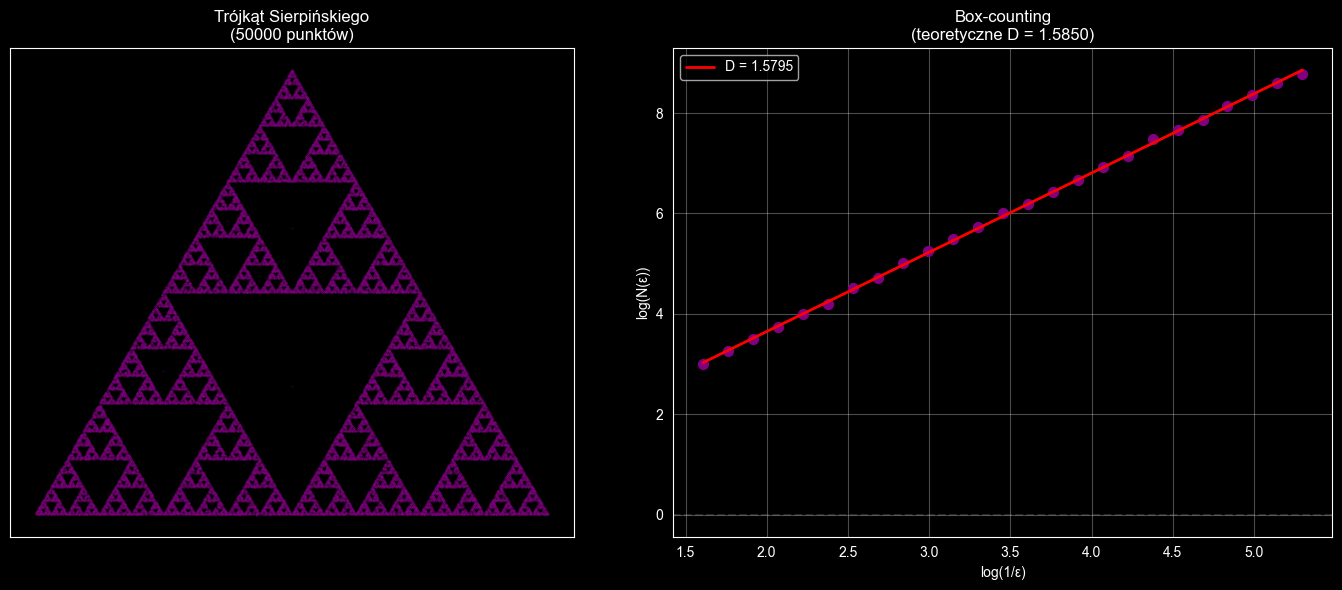

In [7]:
# Wizualizacja trójkąta Sierpińskiego
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lewa - trójkąt
axes[0].scatter(sierpinski_points[:, 0], sierpinski_points[:, 1], s=0.1, alpha=0.5, c='purple')
axes[0].set_aspect('equal')
axes[0].set_title(f'Trójkąt Sierpińskiego\n({len(sierpinski_points)} punktów)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Prawa - box-counting
axes[1].scatter(details_sierpinski['log_inv_eps'], details_sierpinski['log_counts'], s=50, c='purple')
axes[1].plot(details_sierpinski['log_inv_eps'],
             details_sierpinski['slope'] * details_sierpinski['log_inv_eps'] + details_sierpinski['intercept'],
             'r-', linewidth=2, label=f'D = {dim_sierpinski:.4f}')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlabel('log(1/ε)')
axes[1].set_ylabel('log(N(ε))')
axes[1].set_title(f'Box-counting\n(teoretyczne D = {dim_theo_sierpinski:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/figures/sierpinski_box_counting.png', dpi=150)
plt.show()

## 3.3 Dywan Sierpińskiego

Dywan Sierpińskiego to dwuwymiarowy odpowiednik trójkąta:

$$D = \frac{\log 8}{\log 3} \approx 1.893$$

In [8]:
# Generowanie dywanu Sierpińskiego
def sierpinski_carpet(iterations=5):
    """Generuje dywan Sierpińskiego."""
    def is_in_carpet(x, y, size):
        """Sprawdza czy punkt jest w dywanie."""
        while size > 0:
            if (x // size) % 3 == 1 and (y // size) % 3 == 1:
                return False
            size //= 3
        return True
    
    size = 3 ** iterations
    points = []
    
    for x in range(size):
        for y in range(size):
            if is_in_carpet(x, y, size // 3):
                points.append([x / size, y / size])
    
    return np.array(points)

# Generowanie
carpet_points = sierpinski_carpet(5)

# Obliczenie wymiaru
dim_carpet, r2_carpet, details_carpet = box_counting_dimension(
    carpet_points,
    epsilon_min=0.005,
    epsilon_max=0.2,
    n_epsilons=25
)

dim_theo_carpet = np.log(8) / np.log(3)

print("Dywan Sierpińskiego")
print("=" * 50)
print(f"Wymiar teoretyczny: D = log(8)/log(3) = {dim_theo_carpet:.4f}")
print(f"Wymiar obliczony:   D = {dim_carpet:.4f}")
print(f"Błąd względny:      {abs(dim_carpet - dim_theo_carpet)/dim_theo_carpet*100:.2f}%")
print(f"R²:                 {r2_carpet:.4f}")

Dywan Sierpińskiego
Wymiar teoretyczny: D = log(8)/log(3) = 1.8928
Wymiar obliczony:   D = 1.8654
Błąd względny:      1.45%
R²:                 0.9994


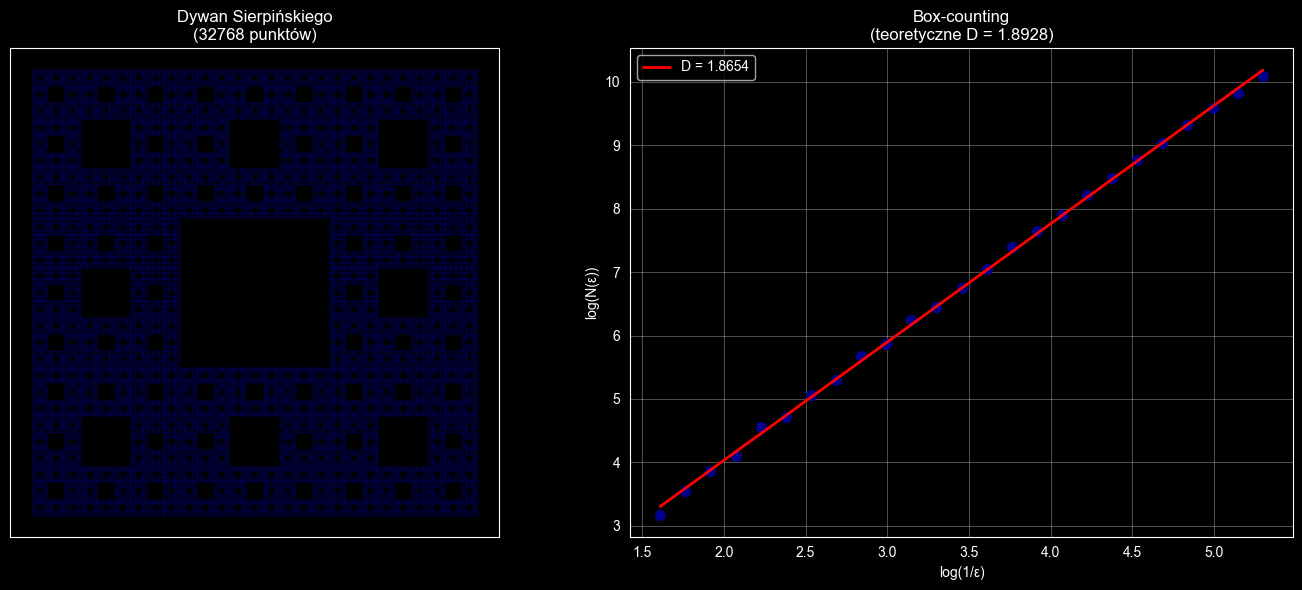

In [9]:
# Wizualizacja dywanu Sierpińskiego
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lewa - dywan
axes[0].scatter(carpet_points[:, 0], carpet_points[:, 1], s=0.1, alpha=0.7, c='darkblue')
axes[0].set_aspect('equal')
axes[0].set_title(f'Dywan Sierpińskiego\n({len(carpet_points)} punktów)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Prawa - box-counting
axes[1].scatter(details_carpet['log_inv_eps'], details_carpet['log_counts'], s=50, c='darkblue')
axes[1].plot(details_carpet['log_inv_eps'],
             details_carpet['slope'] * details_carpet['log_inv_eps'] + details_carpet['intercept'],
             'r-', linewidth=2, label=f'D = {dim_carpet:.4f}')
axes[1].set_xlabel('log(1/ε)')
axes[1].set_ylabel('log(N(ε))')
axes[1].set_title(f'Box-counting\n(teoretyczne D = {dim_theo_carpet:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/figures/carpet_box_counting.png', dpi=150)
plt.show()

## 3.4 Analiza czułości na parametry

Zbadajmy jak wynik zależy od parametrów algorytmu.

In [10]:
# Czułość na liczbę punktów
print("Wpływ liczby punktów na dokładność (trójkąt Sierpińskiego):")
print("=" * 60)

n_points_values = [1000, 5000, 10000, 20000, 50000, 100000]
dims_vs_points = []

for n in n_points_values:
    np.random.seed(42)
    points = sierpinski_chaos(n)
    dim, r2, _ = box_counting_dimension(points, epsilon_min=0.005, epsilon_max=0.2, n_epsilons=20)
    dims_vs_points.append(dim)
    error = abs(dim - dim_theo_sierpinski) / dim_theo_sierpinski * 100
    print(f"n = {n:>6}: D = {dim:.4f}, błąd = {error:.2f}%, R² = {r2:.4f}")

dims_vs_points = np.array(dims_vs_points)

Wpływ liczby punktów na dokładność (trójkąt Sierpińskiego):
n =   1000: D = 1.1031, błąd = 30.40%, R² = 0.9431
n =   5000: D = 1.4518, błąd = 8.40%, R² = 0.9931
n =  10000: D = 1.5350, błąd = 3.15%, R² = 0.9978
n =  20000: D = 1.5611, błąd = 1.51%, R² = 0.9994
n =  50000: D = 1.5808, błąd = 0.27%, R² = 0.9996
n = 100000: D = 1.5819, błąd = 0.19%, R² = 0.9996


In [11]:
# Czułość na zakres epsilon
print("\nWpływ zakresu epsilon na dokładność (trójkąt Sierpińskiego):")
print("=" * 60)

np.random.seed(42)
points_test = sierpinski_chaos(50000)

eps_ranges = [
    (0.001, 0.05),
    (0.005, 0.1),
    (0.005, 0.2),
    (0.01, 0.3),
    (0.02, 0.4)
]

for eps_min, eps_max in eps_ranges:
    dim, r2, _ = box_counting_dimension(points_test, epsilon_min=eps_min, epsilon_max=eps_max, n_epsilons=20)
    error = abs(dim - dim_theo_sierpinski) / dim_theo_sierpinski * 100
    print(f"ε ∈ [{eps_min:.3f}, {eps_max:.2f}]: D = {dim:.4f}, błąd = {error:.2f}%, R² = {r2:.4f}")


Wpływ zakresu epsilon na dokładność (trójkąt Sierpińskiego):
ε ∈ [0.001, 0.05]: D = 1.4258, błąd = 10.04%, R² = 0.9902
ε ∈ [0.005, 0.10]: D = 1.5718, błąd = 0.83%, R² = 0.9995
ε ∈ [0.005, 0.20]: D = 1.5808, błąd = 0.27%, R² = 0.9996
ε ∈ [0.010, 0.30]: D = 1.5878, błąd = 0.18%, R² = 0.9995
ε ∈ [0.020, 0.40]: D = 1.5772, błąd = 0.49%, R² = 0.9983


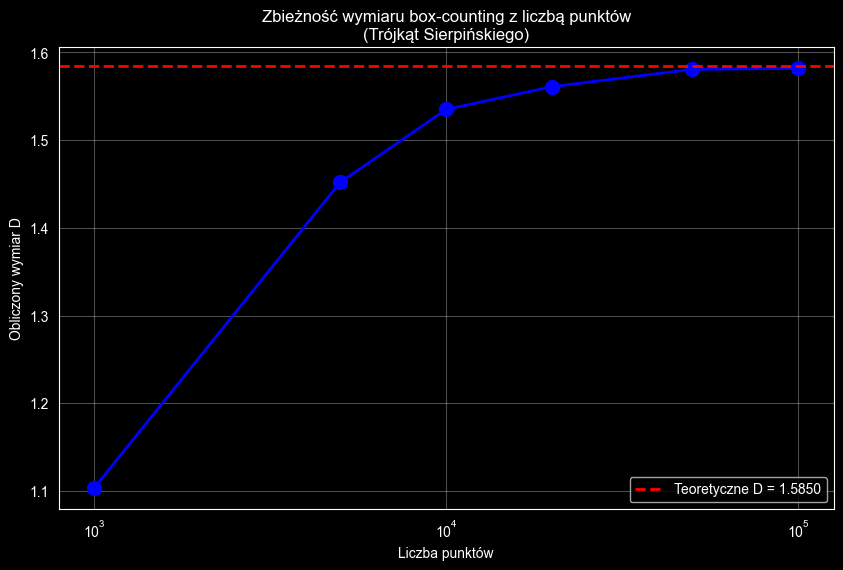

In [12]:
# Wykres czułości na liczbę punktów
plt.figure(figsize=(10, 6))
plt.semilogx(n_points_values, dims_vs_points, 'bo-', markersize=10, linewidth=2)
plt.axhline(y=dim_theo_sierpinski, color='r', linestyle='--', linewidth=2, 
            label=f'Teoretyczne D = {dim_theo_sierpinski:.4f}')
plt.xlabel('Liczba punktów')
plt.ylabel('Obliczony wymiar D')
plt.title('Zbieżność wymiaru box-counting z liczbą punktów\n(Trójkąt Sierpińskiego)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../output/figures/box_counting_convergence.png', dpi=150)
plt.show()

## 3.5 Podsumowanie wyników

### Tabela porównawcza

In [13]:
import pandas as pd

# Zestawienie wszystkich wyników
results = {
    'Obiekt': ['Prosta linia', 'Kwadrat wypełniony', 'Okrąg', 'Trójkąt Sierpińskiego', 'Dywan Sierpińskiego'],
    'D teoretyczne': [1.0, 2.0, 1.0, dim_theo_sierpinski, dim_theo_carpet],
    'D obliczone': [dim_line, dim_square, dim_circle, dim_sierpinski, dim_carpet],
    'R²': [r2_line, r2_square, r2_circle, r2_sierpinski, r2_carpet]
}

df = pd.DataFrame(results)
df['Błąd (%)'] = np.abs(df['D obliczone'] - df['D teoretyczne']) / df['D teoretyczne'] * 100

print("Podsumowanie weryfikacji algorytmu box-counting:")
print("=" * 80)
print(df.to_string(index=False))

# Zapisanie
df.to_csv('../output/data/box_counting_verification.csv', index=False)
print("\nWyniki zapisane do: output/data/box_counting_verification.csv")

Podsumowanie weryfikacji algorytmu box-counting:
               Obiekt  D teoretyczne  D obliczone       R²  Błąd (%)
         Prosta linia       1.000000     0.989514 0.999862  1.048648
   Kwadrat wypełniony       2.000000     1.880293 0.997272  5.985360
                Okrąg       1.000000     0.925330 0.989812  7.466992
Trójkąt Sierpińskiego       1.584963     1.579477 0.999614  0.346110
  Dywan Sierpińskiego       1.892789     1.865388 0.999353  1.447675

Wyniki zapisane do: output/data/box_counting_verification.csv


## 3.6 Wnioski

### Kluczowe obserwacje:

1. **Algorytm box-counting** poprawnie wyznacza wymiar fraktalny dla wszystkich testowanych obiektów.

2. **Dokładność** zależy od:
   - Liczby punktów reprezentujących obiekt
   - Zakresu wartości $\epsilon$
   - Liczby wartości $\epsilon$ w regresji

3. **Zalecenia praktyczne**:
   - Używaj co najmniej 10000 punktów
   - Zakres $\epsilon$ dobierz tak, aby R² > 0.95
   - Unikaj zbyt małych $\epsilon$ (mało pudełek) i zbyt dużych (cały obiekt w jednym pudełku)

4. **Ograniczenia**:
   - Metoda jest przybliżona - wymaga ekstrapolacji do $\epsilon \to 0$
   - Dla skomplikowanych obiektów może być trudno dobrać odpowiedni zakres $\epsilon$